In [30]:
# Import necessary libraries 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import tensorflow 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.regularizers import l1_l2,l1,l2
from tensorflow.keras.optimizers import Adam

### Regularization
<h4>In simple words regularization is the process of penalizing the model to avoid overfitting using different types of penalties.
These penalties are of two types : L1 norm (Lasso) and L2(Ridge).</h4>
Ridge regularization penalizes value by driving weights towards zero but never zero.<br>
Lasso regularization can penalize one step further and create a weight of that node to be zero ,
<br>meaning removing an input directly from that node , causing automatic feature selection.
<br>
<p>Use Ridge regression when all the features are important and use lasso when we can afford removing redundant features </p>

In [13]:
# For this we will be making our custom dataset using make_moons
X, y = make_moons(
                    250, 
                    noise=0.23,
                    random_state=15
                    )

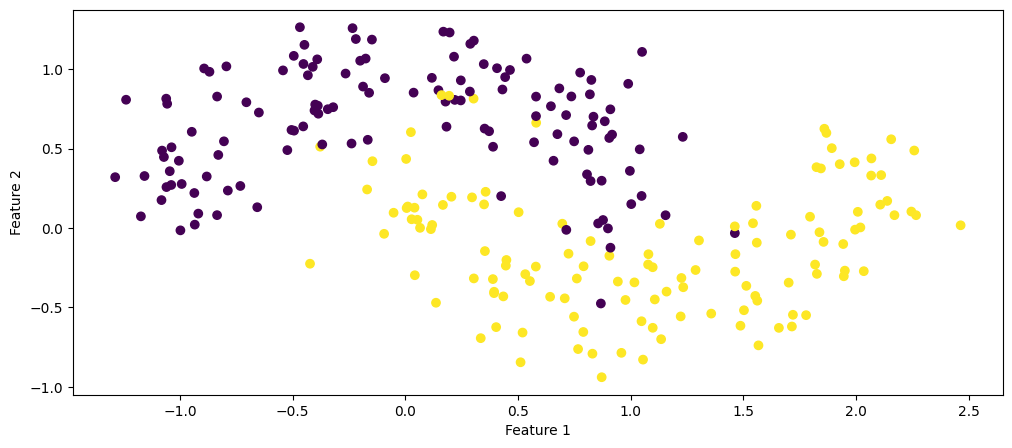

In [14]:
# Let's Visualize this 
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [15]:
# Now let's split the dataset for our model training later
X_train,X_test,y_train,y_test = train_test_split(
                                                    X,y,
                                                    test_size = 0.2,
                                                    random_state = 42
)

In [16]:
# Now let's train the model without regularization and check it's performance

In [51]:
# Instantiating the model with a simple classification setup where the activation function for the hidden layer is relu and the 
# activation function for the final output layer is sigmoid

model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary() # There are a total of  17,025 params

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Model compiling using an explicit learning rate for adam and fitting 

adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history = model.fit(X, y, epochs=250, validation_data=(X_test,y_test),verbose=1)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.8000 - loss: 0.4310 - val_accuracy: 0.9000 - val_loss: 0.3706
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8840 - loss: 0.2951 - val_accuracy: 0.9000 - val_loss: 0.2955
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9040 - loss: 0.2778 - val_accuracy: 0.9000 - val_loss: 0.2711
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9080 - loss: 0.2504 - val_accuracy: 0.9000 - val_loss: 0.2602
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9240 - loss: 0.2184 - val_accuracy: 0.9000 - val_loss: 0.2497
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9320 - loss: 0.1930 - val_accuracy: 0.9000 - val_loss: 0.2194
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9440 - loss: 0.1704 - val_accuracy: 0.9000 - val_loss: 0.2026
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9320 - loss: 0.1880 - val_accuracy: 0.9200 - val_loss:

In [53]:
model_norm_weights_layer1 = model.get_weights()[0].reshape(256)

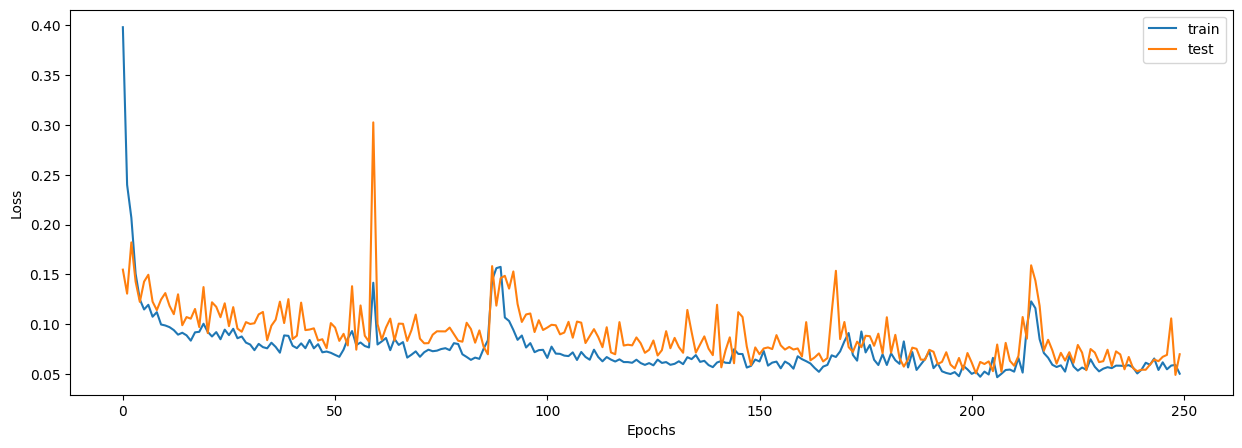

In [ ]:
# Now lets plot this into the graph
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Really good to be honest the model converges well

23438/23438 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step


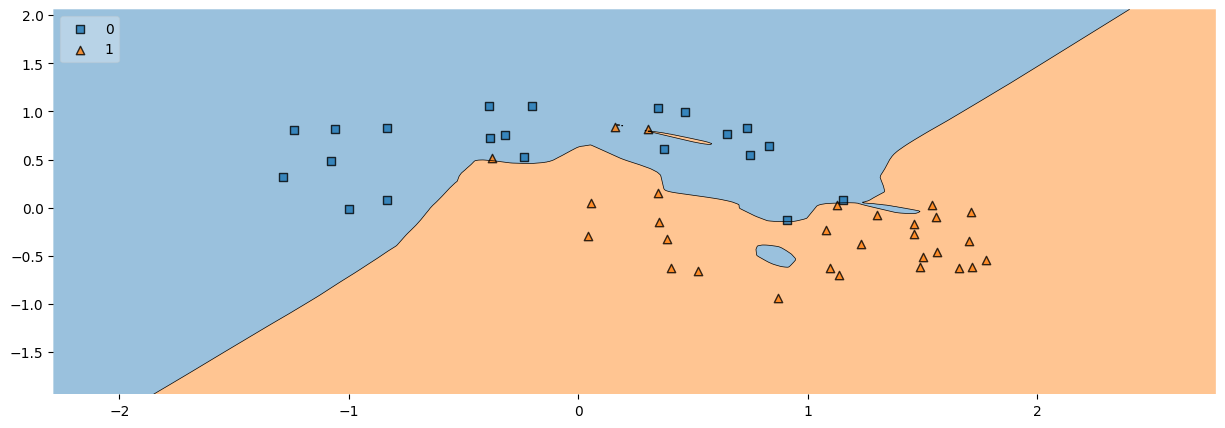

In [24]:
# Also plot the decision boundary to look for how well the model fits the data
plt.figure(figsize=(15,5))
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [25]:
# Yeah this reveal this true pattern of the model , now as we can see the lakes forming ; the model is learning values and it;s position
# and not generalizing well , we need a smoother curve which will help to make a generalized well decision when a newer value is predicted

In [26]:
# Now we will do the same steps but pass the regularization penalty lambda as parameter

In [27]:
# Let's apply first l2 norm

In [31]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

# Here in the hidden layers we will add the regularization parameter

model.add(Dense(128,activation='relu',kernel_regularizer=l2(0.001)))
model.add(Dense(128,activation='relu',kernel_regularizer=l2(0.001)))

model.add(Dense(1,activation='sigmoid'))

model.summary() 

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
history = model.fit(X, y, epochs=250, validation_data=(X_test,y_test),verbose=1)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 287ms/step - accuracy: 0.7680 - loss: 0.5305 - val_accuracy: 0.8600 - val_loss: 0.4463
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8680 - loss: 0.4185 - val_accuracy: 0.9000 - val_loss: 0.3723
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8880 - loss: 0.3494 - val_accuracy: 0.9000 - val_loss: 0.3367
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9040 - loss: 0.3190 - val_accuracy: 0.9000 - val_loss: 0.3341
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9040 - loss: 0.2932 - val_accuracy: 0.9000 - val_loss: 0.3140
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9160 - loss: 0.2735 - val_accuracy: 0.9000 - val_loss: 0.3086
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9200 - loss: 0.2494 - val_accuracy: 0.9000 - val_loss: 0.2738
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9320 - loss: 0.2231 - val_accuracy: 0.9000 - val_loss

In [39]:
model_l1_weights_layer1 = model.get_weights()[0].reshape(256) # Store weights for future comparision

In [33]:
# Now we plot again the graphs to look for any changes found

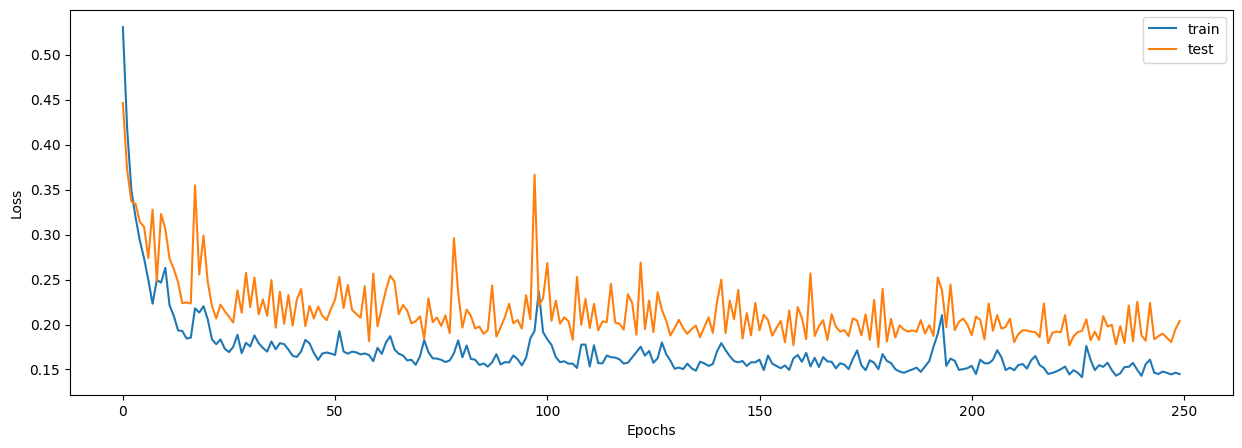

In [34]:
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

23438/23438 ━━━━━━━━━━━━━━━━━━━━ 75s 3ms/step


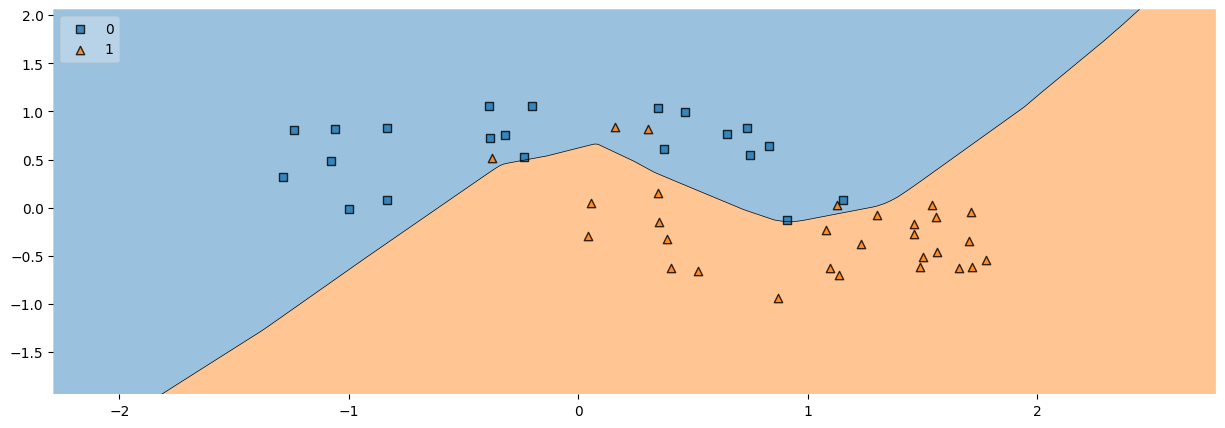

In [35]:
plt.figure(figsize=(15,5))
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [40]:
# Really good , now then model is no more overfittin and generalizing well

In [41]:
# Now let's try the l1 norm

In [42]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

# Here in the hidden layers we will add the regularization parameter

model.add(Dense(128,activation='relu',kernel_regularizer=l1(0.001)))
model.add(Dense(128,activation='relu',kernel_regularizer=l1(0.001)))

model.add(Dense(1,activation='sigmoid'))

model.summary() 

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
history = model.fit(X, y, epochs=250, validation_data=(X_test,y_test),verbose=1)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.7680 - loss: 1.4245 - val_accuracy: 0.8600 - val_loss: 0.9702
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8720 - loss: 0.7823 - val_accuracy: 0.9000 - val_loss: 0.6912
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8880 - loss: 0.6137 - val_accuracy: 0.9000 - val_loss: 0.5523
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8800 - loss: 0.5311 - val_accuracy: 0.9000 - val_loss: 0.4890
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8680 - loss: 0.4762 - val_accuracy: 0.9000 - val_loss: 0.4589
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9000 - loss: 0.4505 - val_accuracy: 0.9000 - val_loss: 0.4427
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8880 - loss: 0.4228 - val_accuracy: 0.9000 - val_loss: 0.4135
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8760 - loss: 0.4123 - val_accuracy: 0.9000 - val_loss

In [44]:
model_l2_weights_layer1 = model.get_weights()[0].reshape(256) # Store weights for future comparision

In [45]:
# Plotting the graphs again

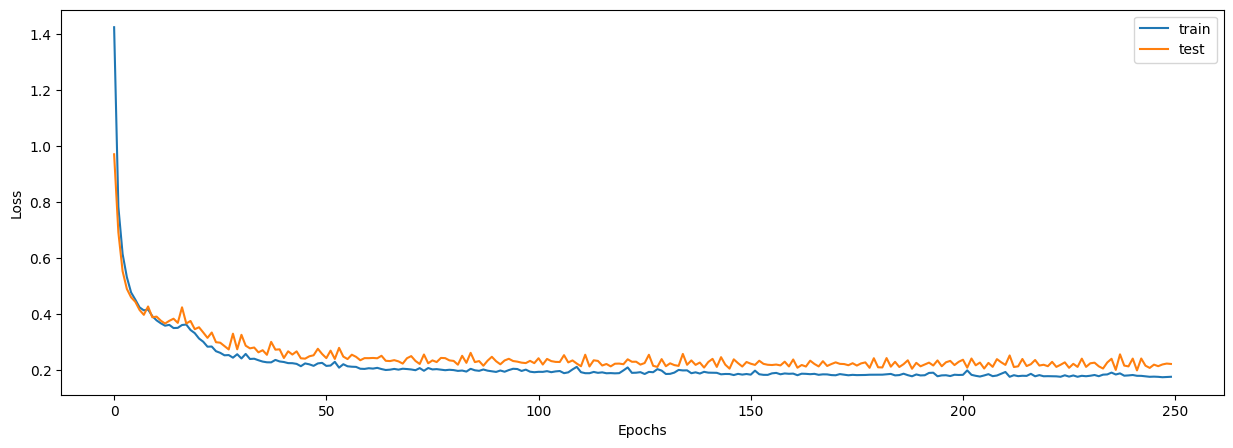

In [48]:
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
# Yeah we can clearly look that the jaggerdness in th previous graphs are gone we can clearly see the difference

23438/23438 ━━━━━━━━━━━━━━━━━━━━ 75s 3ms/step


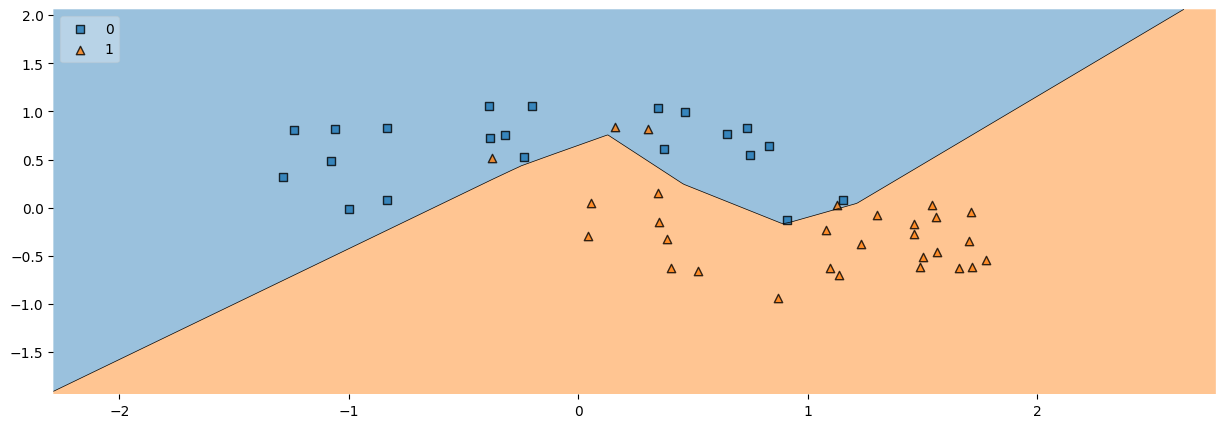

In [47]:
plt.figure(figsize=(15,5))
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

In [49]:
# Looks similar to the l2 norm but the edges are more sharp I guess

In [50]:
# Now we will compare the model weights of all the model with a boxplot and kdeplot to look what exactly happened to their values

In [60]:
# A custom dataframe that contains weights of all the models 
# Why did I do this ? Cause seaborn works well with dataframes
df = pd.DataFrame(
                    {
                        'normal' : model_norm_weights_layer1,
                        'ridge' : model_l2_weights_layer1,
                        'lasso' : model_l1_weights_layer1
                    }
)

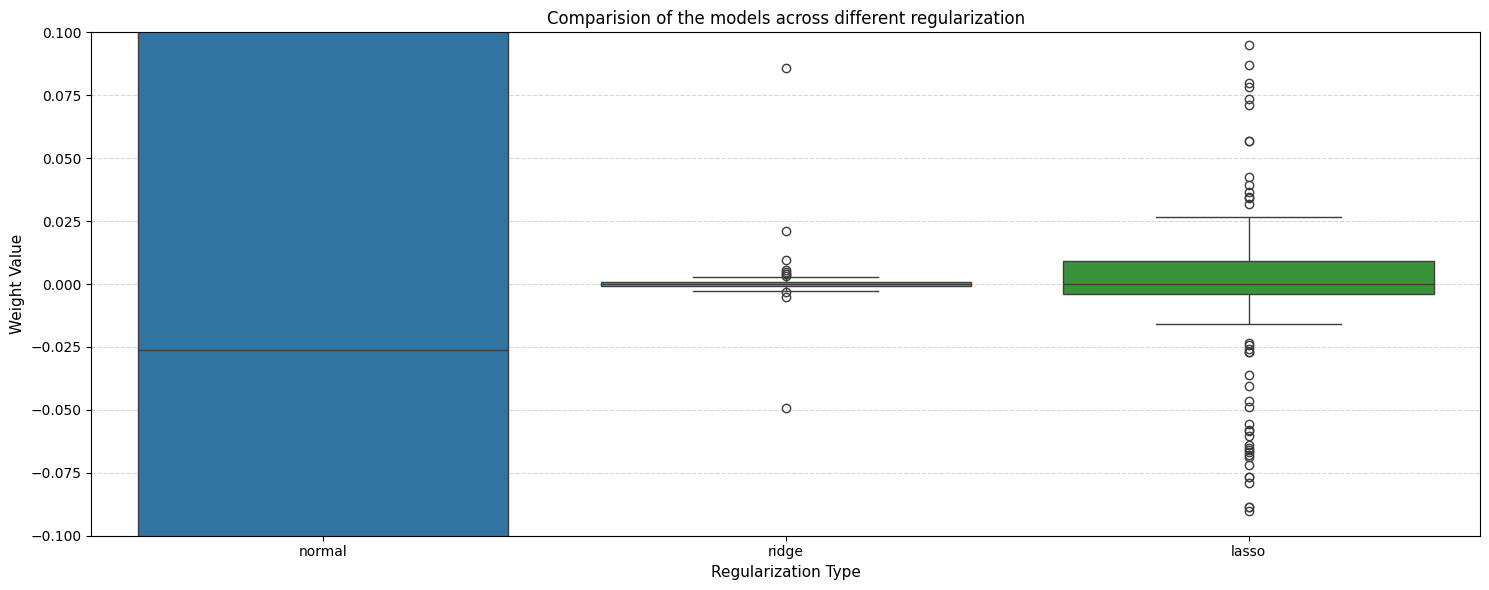

In [71]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.title('Comparision of the models across different regularization')
plt.ylabel('Weight Value', fontsize=11)
plt.xlabel('Regularization Type', fontsize=11)
plt.ylim(-0.1, 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.5) # Adds a clean grid to read values easily
plt.tight_layout()
plt.show()

In [ ]:
'''
1. Normal ANN (No Regularization)

    High Variance: The weights have a very wide spread that expands
    completely past the upper and lower bounds of your zoomed axis (\(>0.10\) and \(< -0.10\)).

    No Penalty: The model uses large weight magnitudes because nothing is restricting their growth,
    leaving the network vulnerable to overfitting.Symmetric Spread: The median weight sits just below 0.0, 
    with a balanced distribution of positive and negative coefficients.
 
2. Ridge (L2 Regularization)

    Extreme Compression: This model features the tightest box layout on the graph, 
    concentrated heavily around 0.0.

    Proportional Shrinkage: The math forces almost all weights to be uniform and tiny, 
    resulting in a very flat interquartile range (IQR).
    
    Non-Zero Minimums: While the weights are heavily restricted and packed together, t
    hey maintain tiny fractional values rather than hitting absolute zero.
 
3. Lasso (L1 Regularization)

    Sparse Box: The main box is tightly flattened around 0.0,visually demonstrating that the majority of irrelevant features have 
    had their weights driven to exactly zero.

    Heavy Outliers: A distinct, elongated trail of outlier dots extends both upward and downward.

    Feature Selection: These outliers represent the specific, highly influential input features 
    that the model chose to preserve to make its predictions.
    

'''

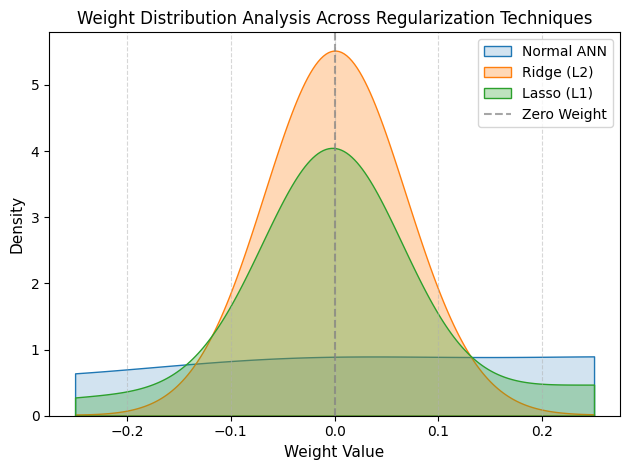

In [76]:
# Now let's create a kdeplot to look for the distribution

custom_palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

sns.kdeplot(data=df['normal'], label='Normal ANN', color=custom_palette[0], fill=True, alpha=0.2, clip=(-0.25, 0.25))
sns.kdeplot(data=df['ridge'], label='Ridge (L2)', color=custom_palette[1], fill=True, alpha=0.3, clip=(-0.25, 0.25))
sns.kdeplot(data=df['lasso'], label='Lasso (L1)', color=custom_palette[2], fill=True, alpha=0.3, clip=(-0.25, 0.25))

# Add a vertical reference line at exactly 0.0 to emphasize the zeroing effect
plt.axvline(x=0.0, color='gray', linestyle='--', alpha=0.7, label='Zero Weight')

# Plot styling
plt.title('Weight Distribution Analysis Across Regularization Techniques', fontsize=12)
plt.xlabel('Weight Value', fontsize=11)
plt.ylabel('Density', fontsize=11)

# Display the legend to identify the models
plt.legend(loc='upper right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

In [77]:
# With this graph we can clearly look the effect of regualrization on weights